In [40]:
import pandas as pd

df = pd.read_csv("E:/B-Tech/AI_ML/ASSIGNMENT/pbl_dataset.csv")
print(df.head())

   S NO.  Age  Gender  Income     Employment  LoanAmount  LoanTerm  \
0      1   25    Male  300000       Salaried      100000        24   
1      2   40  Female  800000  Self-employed      300000        36   
2      3   35    Male  500000       Salaried      200000        48   
3      4   29  Female  450000       Salaried      150000        36   
4      5   50    Male  900000       Business      400000        60   

   InterestRate  CreditScore   DTI  PastDefaults  NumLoans  Savings    EMI  \
0          10.5          720  0.25             0         1    50000   4600   
1          12.2          680  0.35             1         2   150000  10000   
2          11.0          590  0.45             2         3    80000   6000   
3           9.5          710  0.28             0         1    60000   4800   
4          13.5          550  0.50             3         4   200000  12000   

   Default  Unnamed: 15  
0        0          NaN  
1        0          NaN  
2        1          NaN  
3     

In [41]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   S NO.         100 non-null    int64  
 1   Age           100 non-null    int64  
 2   Gender        100 non-null    str    
 3   Income        100 non-null    int64  
 4   Employment    100 non-null    str    
 5   LoanAmount    100 non-null    int64  
 6   LoanTerm      100 non-null    int64  
 7   InterestRate  100 non-null    float64
 8   CreditScore   100 non-null    int64  
 9   DTI           100 non-null    float64
 10  PastDefaults  100 non-null    int64  
 11  NumLoans      100 non-null    int64  
 12  Savings       100 non-null    int64  
 13  EMI           100 non-null    int64  
 14  Default       100 non-null    int64  
 15  Unnamed: 15   0 non-null      float64
dtypes: float64(3), int64(11), str(2)
memory usage: 12.6 KB
None
            S NO.         Age        Income    LoanAmount    LoanTer

In [42]:
df = df.ffill()

In [43]:
df['Employment']=df['Employment'].str.replace('-','')
df['Employment']=df['Employment'].str.strip()

In [44]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Employment']=le.fit_transform(df['Employment'])

In [45]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['Employment']])

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                  'InterestRate', 'CreditScore', 'DTI',
                  'Savings', 'EMI']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_cols = ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                  'InterestRate', 'CreditScore', 'DTI',
                  'Savings', 'EMI']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

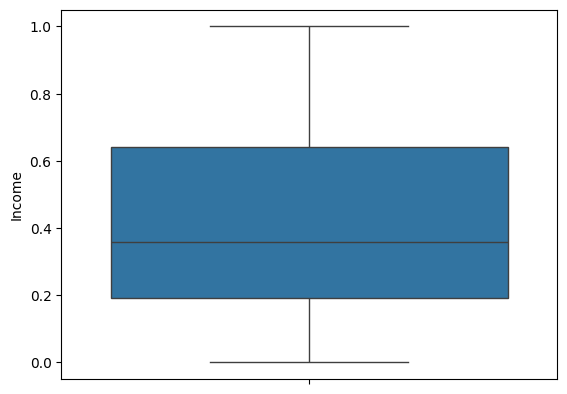

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df['Income'])
plt.show()

In [49]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Income'] >= Q1 - 1.5*IQR) & (df['Income'] <= Q3 + 1.5*IQR)]

In [50]:
df.to_csv("E:/B-Tech/AI_ML/ASSIGNMENT/processed_dataset.csv",index=False)